# Processamento de Sinais I — Aula Prática 2
## Questão 5 — Subamostragem com `scipy.signal.resample()`

Objetivo: repetir a subamostragem da questão anterior com `resample()` e comparar os resultados com a função própria.

## Importar bibliotecas e carregar a função de espectro

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from scipy.io import wavfile
from scipy import signal

def load_calculate_spectrum():
    notebook_path = Path('../tools/calculate_spectrum.ipynb')
    notebook = json.loads(notebook_path.read_text(encoding='utf-8'))

    namespace = {}
    for cell in notebook['cells']:
        if cell.get('cell_type') != 'code':
            continue

        source = ''.join(cell.get('source', []))
        exec(source, namespace)
        if 'calculate_spectrum' in namespace:
            return namespace['calculate_spectrum']

    raise RuntimeError('calculate_spectrum() nao encontrada em ../tools/calculate_spectrum.ipynb')

calculate_spectrum = load_calculate_spectrum()

plt.style.use('seaborn-v0_8-whitegrid')

def to_float_mono(data):
    data = np.asarray(data)
    if data.ndim > 1:
        data = data.mean(axis=1)
    if np.issubdtype(data.dtype, np.integer):
        data = data.astype(np.float64) / np.iinfo(data.dtype).max
    else:
        data = data.astype(np.float64)
    peak = np.max(np.abs(data))
    if peak > 1:
        data = data / peak
    return data


def show_audio(audio, rate, label):
    print(label)
    display(Audio(audio, rate=rate))


def plot_spectrum(signal_in, sampling_frequency, title, max_frequency=None):
    freqs, amps = calculate_spectrum(signal_in, sampling_frequency, single_sided=True)
    plt.figure(figsize=(12, 4))
    plt.plot(freqs, amps)
    if max_frequency is not None:
        plt.xlim(0, max_frequency)
    plt.title(title)
    plt.xlabel('Frequencia (Hz)')
    plt.ylabel('Amplitude')
    plt.tight_layout()
    return freqs, amps


## Definir a função própria e gerar as duas versões

In [2]:
def subamostrar(signal_in, fator):
    return signal_in[::fator]


fs, audio_int = wavfile.read('../data/handel.wav')
audio = to_float_mono(audio_int)
fatores = [2, 4, 8]

resultados = {}
for M in fatores:
    proprio = subamostrar(audio, M)
    resampleado = signal.resample(audio, len(audio) // M)
    resultados[M] = {'Propria': proprio, 'scipy.signal.resample': resampleado}


## Comparar no tempo, no espectro e na audição

Audio Propria com M = 2


Audio scipy.signal.resample com M = 2


Audio Propria com M = 4


Audio scipy.signal.resample com M = 4


Audio Propria com M = 8


Audio scipy.signal.resample com M = 8


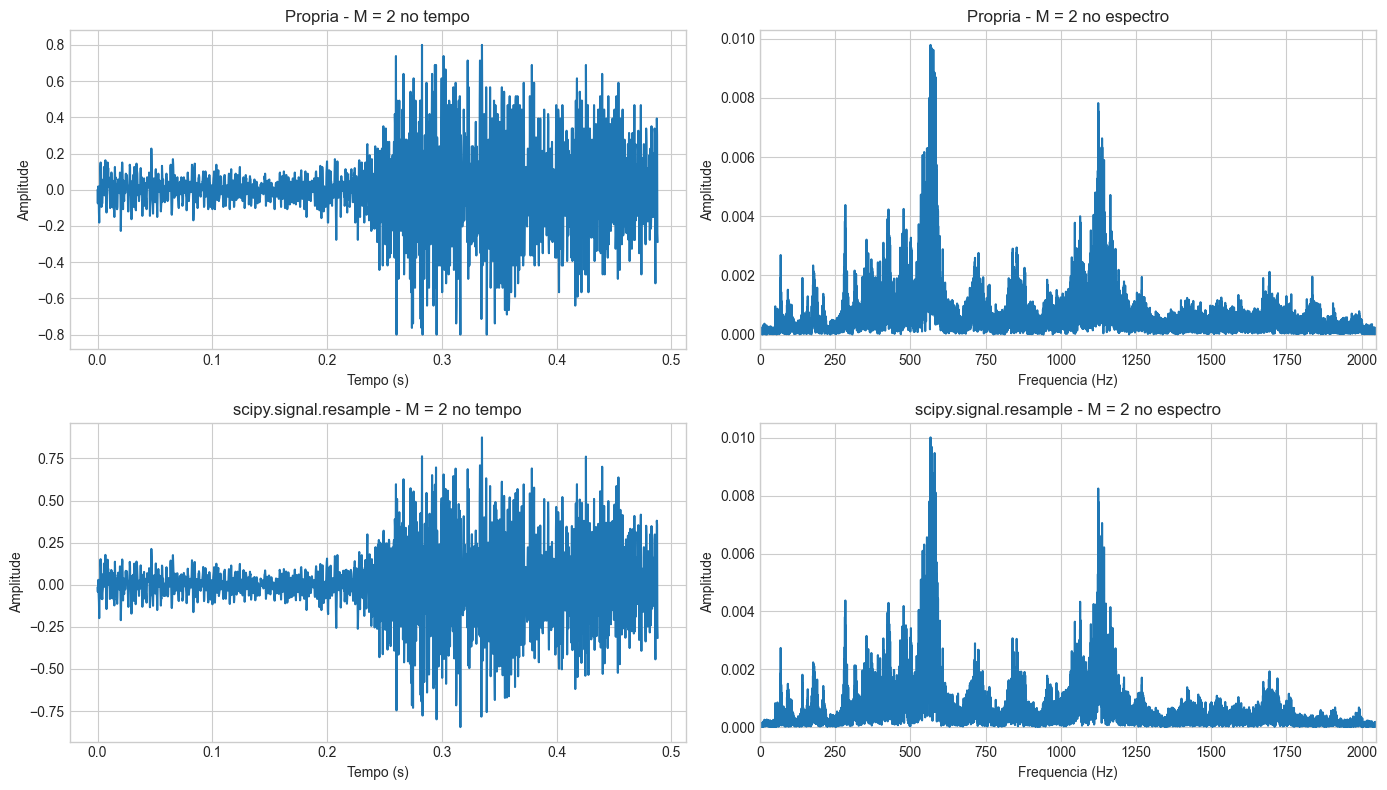

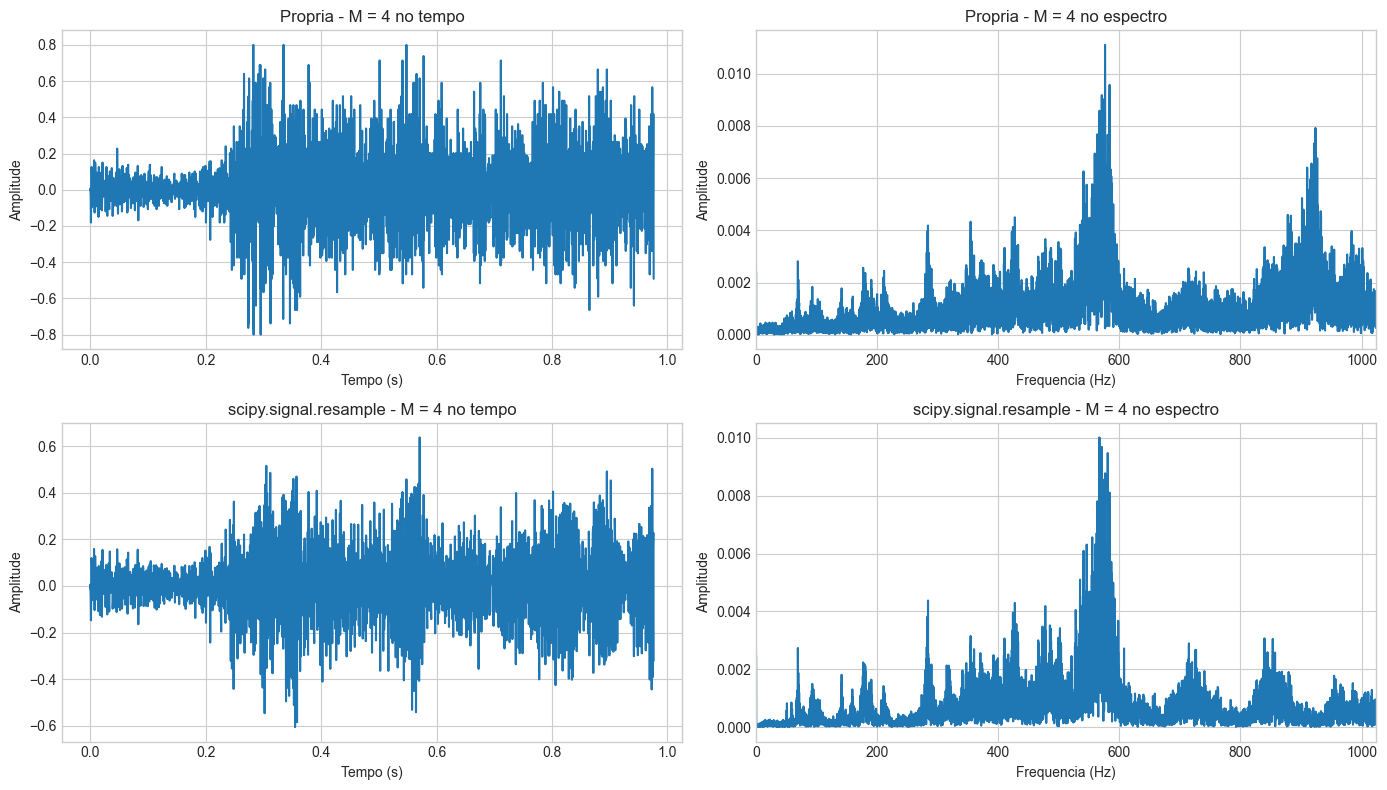

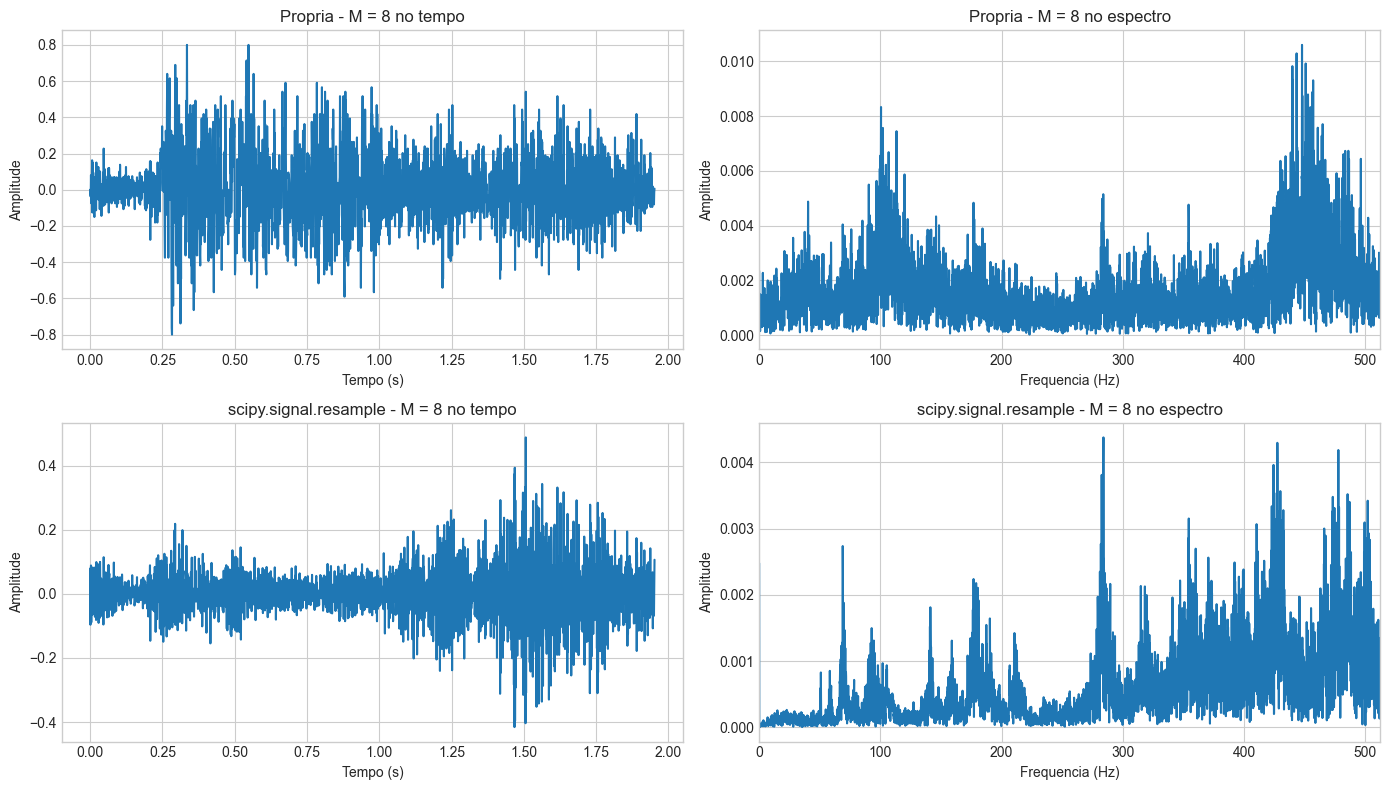

In [3]:
for M in fatores:
    taxa = fs // M
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    for i, (nome, y) in enumerate(resultados[M].items()):
        tempo = np.arange(len(y)) / taxa
        axes[i, 0].plot(tempo[:2000], y[:2000])
        axes[i, 0].set_title(f'{nome} - M = {M} no tempo')
        axes[i, 0].set_xlabel('Tempo (s)')
        axes[i, 0].set_ylabel('Amplitude')

        freqs, amps = calculate_spectrum(y, taxa, single_sided=True)
        axes[i, 1].plot(freqs, amps)
        axes[i, 1].set_xlim(0, taxa / 2)
        axes[i, 1].set_title(f'{nome} - M = {M} no espectro')
        axes[i, 1].set_xlabel('Frequencia (Hz)')
        axes[i, 1].set_ylabel('Amplitude')

    plt.tight_layout()

    for nome, y in resultados[M].items():
        show_audio(y, taxa, f'Audio {nome} com M = {M}')


## Comentários

A função própria implementa a subamostragem direta por descarte de amostras, o que preserva exatamente a definição matemática, mas não evita aliasing.

Já `scipy.signal.resample()` usa interpolação no domínio da frequência para produzir um sinal com novo número de amostras, normalmente com resultado mais suave. Em geral, o espectro e a audição ficam menos degradados do que na simples retirada de amostras.